In [17]:
def heapify(A, n, i):
    # Assume root is largest
    largest = i
    left = 2 * i + 1 # left child index
    right = 2 * i + 2 # right child index
    
    # check if left child exists and is > root
    if left < n and A[left] > A[largest]:
        largest = left
    # check if right child exists and is > largest
    if right < n and A[right] > A[largest]:
        largest = right
    # if largest is not the root, swap and heapify subtree
    if largest != i:
        A[i], A[largest] = A[largest], A[i]
        heapify(A, n, largest)

In [18]:
def build_heap(A, n):
    
    # build max heap from array
    for i in range(n // 2 - 1, -1, -1):
        heapify(A, n, i)

In [19]:
def heap_sort(A):
    n = len(A)
    
    if n <= 1:
        return

    build_heap(A, n)
    
    n -= 1
    # move max to end, re-heapify
    while n > 0:
        A[0], A[n] = A[n], A[0]
        heapify(A, n, 0)
        n -= 1

In [20]:
def merge(A, left, mid, right):
    # n1 and n2 are the sizes of subarrays to merge
    n1 = mid - left + 1
    n2 = right - mid
    
    # temp left and right arrays
    L = [0] * n1
    R = [0] * n2
    
    # copy data to temps
    for i in range(n1):
        L[i] = A[left + i]
    for j in range(n2):
        R[j] = A[mid + 1 + j]
        
    i = 0 # L index
    j= 0 # R index
    k = left # merged array index
    
    # merge by comparing L and R
    while i < n1 and j < n2:
        if L[i] <= R[j]:
            A[k] = L[i]
            i += 1
        else:
            A[k] = R[j]
            j += 1
        k += 1
    
    # copy remaining elements from L
    while i < n1:
        A[k] = L[i]
        i += 1
        k += 1
    
    # copy remaining elements from R    
    while j < n2:
        A[k] = R[j]
        j += 1
        k += 1

In [21]:
def merge_sort(A, left, right):
    if left < right:
        mid = (left + right) // 2 # find midpoint
        merge_sort(A, left, mid) # recurse on left half
        merge_sort(A, mid + 1, right) # recurse of right half
        if A[mid] > A[mid + 1]: # early exit check
            merge(A, left, mid, right)

In [22]:
import time
import random

merge_times = []
heap_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)

In [ ]:
# plot times against input sizes
import matplotlib.pyplot as plt

plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# source: https://cs.stackexchange.com/questions/108968/can-this-double-pop-heapsort-variation-speed-up-sorting-on-average
def dp_heap_sort(A):
    n = len(A)
    
    if n <=1:
        return
    
    build_heap(A, n)
        
    n -= 1
    while n > 2:
        # place max at sorted end of array
        A[0], A[n] = A[n], A[0]
        n -= 1
        
        # 2nd largest is larger child of root
        # place at next sorted position
        if A[1] >= A[2]:
            A[1], A[n] = A[n], A[1]
            heapify(A, n, 1) # re-heapify below left child
        else:
            A[2], A[n] = A[n], A[2]
            heapify(A, n, 2) # re-heapify below right child

        heapify(A, n, 0) # restore max heap property
        n -= 1
        
    # regular heap sort for last 3 elements
    while n > 0:
        A[0], A[n] = A[n], A[0]
        heapify(A, n, 0)
        n -= 1

In [26]:
merge_times = []
heap_times = []
dpop_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    dpop_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
        
        # time dpop sort execution
        arr_dpop = A[:]
        start = time.perf_counter()
        dp_heap_sort(arr_dpop)
        dpop_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)
    dpop_times.append(sum(dpop_trials) / trials)

In [ ]:
plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.plot(sizes, dpop_times, marker='D', label="Double Pop Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort vs Double Pop Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
"""merge_times = []
heap_times = []
dpop_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000, 100000, 500000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    dpop_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
        
        # time dpop sort execution
        arr_dpop = A[:]
        start = time.perf_counter()
        dp_heap_sort(arr_dpop)
        dpop_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)
    dpop_times.append(sum(dpop_trials) / trials)"""

'merge_times = []\nheap_times = []\ndpop_times = []\n\nsizes = [500, 2000, 4000, 6000, 8000, 10000, 100000, 500000] # input sizes\ntrials = 10 # trials per input size\n\nfor n in sizes:\n    merge_trials = []\n    heap_trials = []\n    dpop_trials = []\n    \n    for _ in range(trials):\n        # random array of n unique elements\n        A = random.sample(range(n * 10), n)\n        \n        # time merge sort execution\n        A_merge = A[:]\n        start = time.perf_counter()\n        merge_sort(A_merge, 0, len(A_merge) - 1)\n        merge_trials.append(time.perf_counter() - start)\n        \n        # time heap sort execution\n        A_heap = A[:]\n        start = time.perf_counter()\n        heap_sort(A_heap)\n        heap_trials.append(time.perf_counter() - start)\n        \n        # time dpop sort execution\n        arr_dpop = A[:]\n        start = time.perf_counter()\n        dp_heap_sort(arr_dpop)\n        dpop_trials.append(time.perf_counter() - start)\n    \n    # store 

In [29]:
"""plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.plot(sizes, dpop_times, marker='D', label="Double Pop Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort vs Double Pop Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()"""

'plt.plot(sizes, merge_times, marker=\'o\', label = "Merge Sort")\nplt.plot(sizes, heap_times, marker=\'s\', label="Heap Sort")\nplt.plot(sizes, dpop_times, marker=\'D\', label="Double Pop Heap Sort")\nplt.xlabel("Input Size (n)")\nplt.ylabel("Average Time (s)")\nplt.title("Merge Sort vs Heap Sort vs Double Pop Heap Sort")\nplt.legend()\nplt.grid(True)\nplt.tight_layout()\nplt.show()'

In [33]:
import random
import string
import tracemalloc

# measure peak memory allocation
def measure_memory(fn, arr):
    tracemalloc.start()
    fn(arr)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024 # peak mem usage in KB

# input generators
def gen_ints(n):
    return random.sample(range(n * 10), n)

def gen_floats(n):
    return [random.uniform(0, n * 10) for _ in range(n)]

def gen_strings(n, length=6):
    return [''.join(random.choices(string.ascii_lowercase, k=length)) for _ in range(n)]

def gen_random(n):
    return random.sample(range(n * 10), n)

def gen_sorted(n):
    return list(range(n))

def gen_reverse(n):
    return list(range(n, 0, -1))

def gen_nearly_sorted(n, swaps=None):
    A = list(range(n))
    swaps = swaps or n // 20  # swap ~5% of elements
    for _ in range(swaps):
        i, j = random.randrange(n), random.randrange(n)
        A[i], A[j] = A[j], A[i]
    return A

def gen_many_duplicates(n):
    return [random.randint(0, n // 10) for _ in range(n)]  # few unique values

input_types = {
    "Integers": gen_ints,
    "Floats":   gen_floats,
    "Strings":  gen_strings,
    "Random":         gen_random,
    "Sorted":         gen_sorted,
    "Reverse Sorted": gen_reverse,
    "Nearly Sorted":  gen_nearly_sorted,
    "Many Duplicates": gen_many_duplicates,
}

sizes  = [500, 2000, 4000, 6000, 8000, 10000]
trials = 10

results = {}
mem_results = {}

for type_name, gen in input_types.items():
    merge_times, heap_times, dpop_times = [], [], []
    merge_mem, heap_mem, dpop_mem = [], [], []
    for n in sizes:
        mt, ht, dt = [], [], []
        mm, hm, dm = [], [], []
        for _ in range(trials):
            A = gen(n)
            for arr, lst, fn in [
                (A[:], mt, lambda a: merge_sort(a, 0, len(a)-1)),
                (A[:], ht, heap_sort),
                (A[:], dt, dp_heap_sort),
            ]:
                start = time.perf_counter()
                fn(arr)
                lst.append(time.perf_counter() - start)
            mm.append(measure_memory(lambda a: merge_sort(a, 0, len(a)-1), A[:]))
            hm.append(measure_memory(heap_sort, A[:]))
            dm.append(measure_memory(dp_heap_sort, A[:]))
        merge_times.append(sum(mt) / trials)
        heap_times.append(sum(ht) / trials)
        dpop_times.append(sum(dt) / trials)
        merge_mem.append(sum(mm) / trials)
        heap_mem.append(sum(hm) / trials)
        dpop_mem.append(sum(dm) / trials)
    results[type_name] = {"merge": merge_times, "heap": heap_times, "dpop": dpop_times}
    mem_results[type_name] = {"merge": merge_mem, "heap": heap_mem, "dpop": dpop_mem}


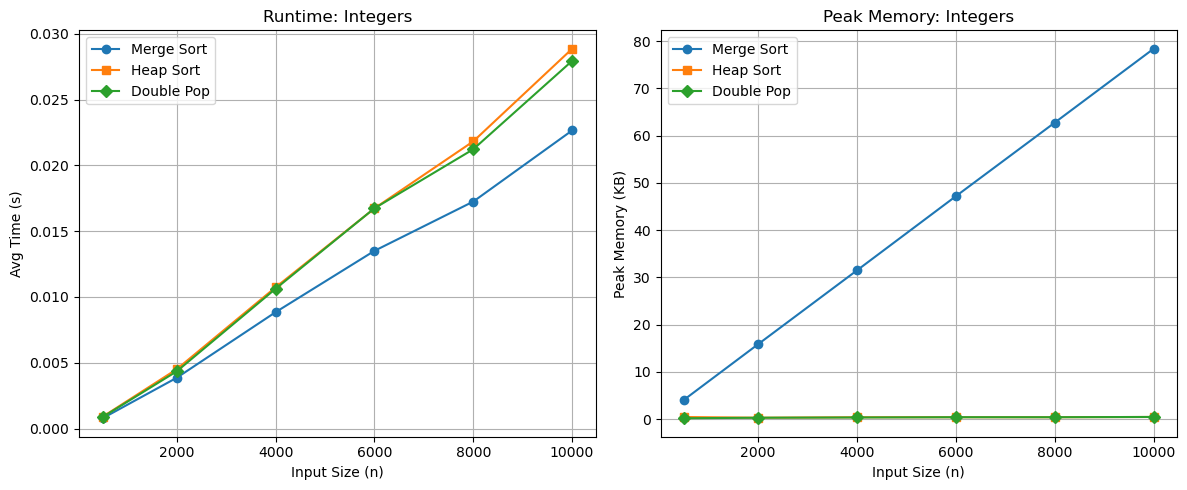

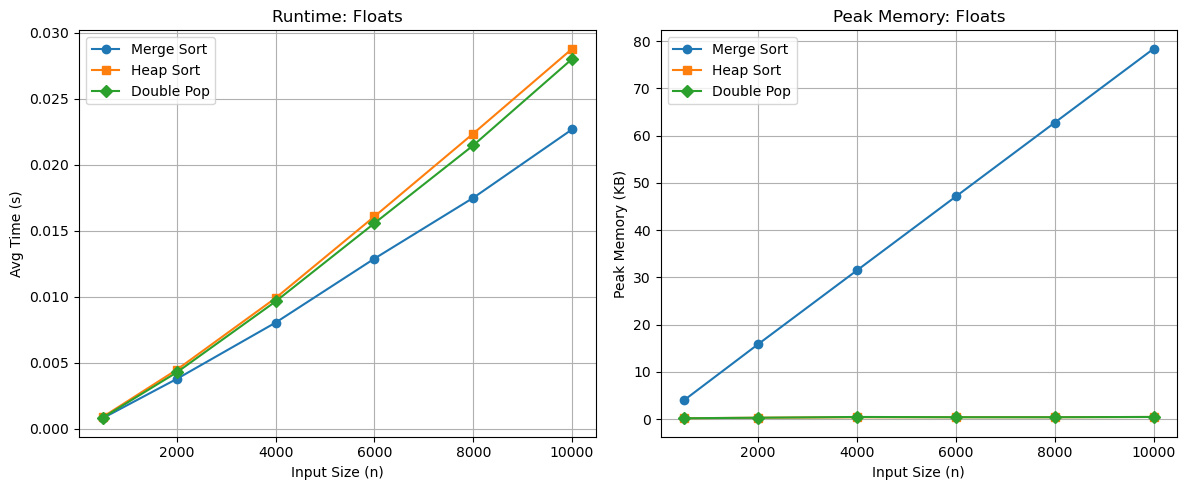

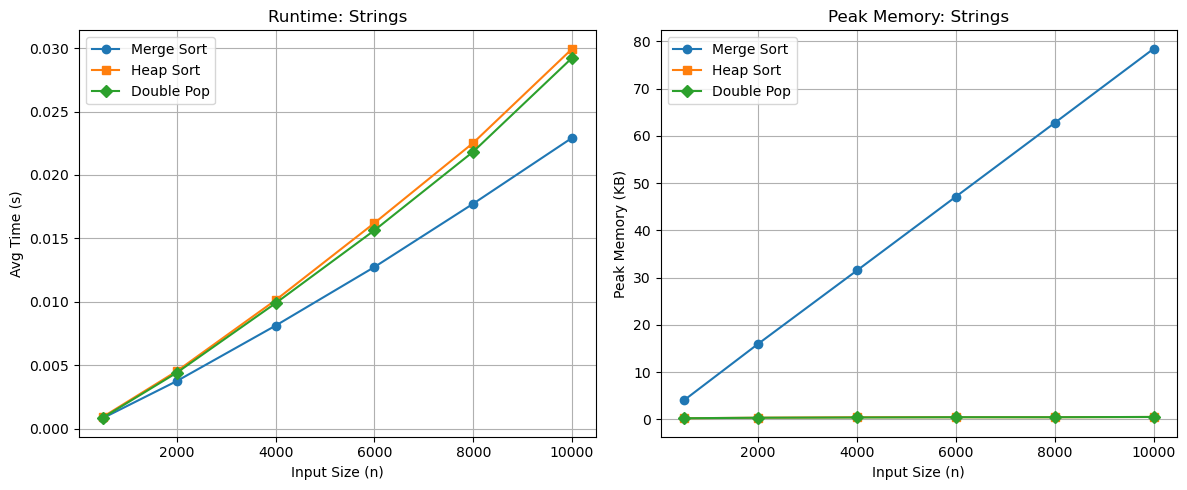

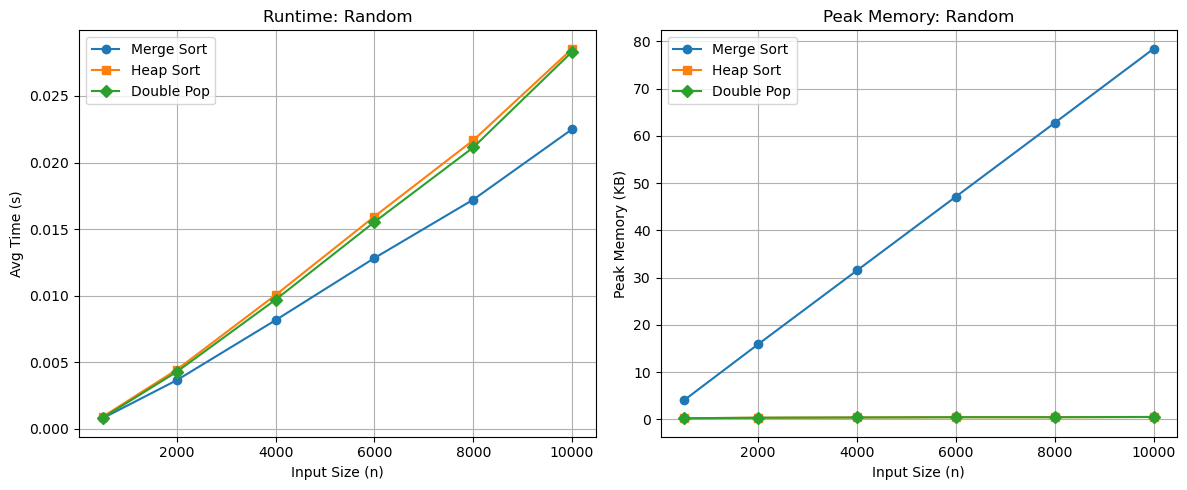

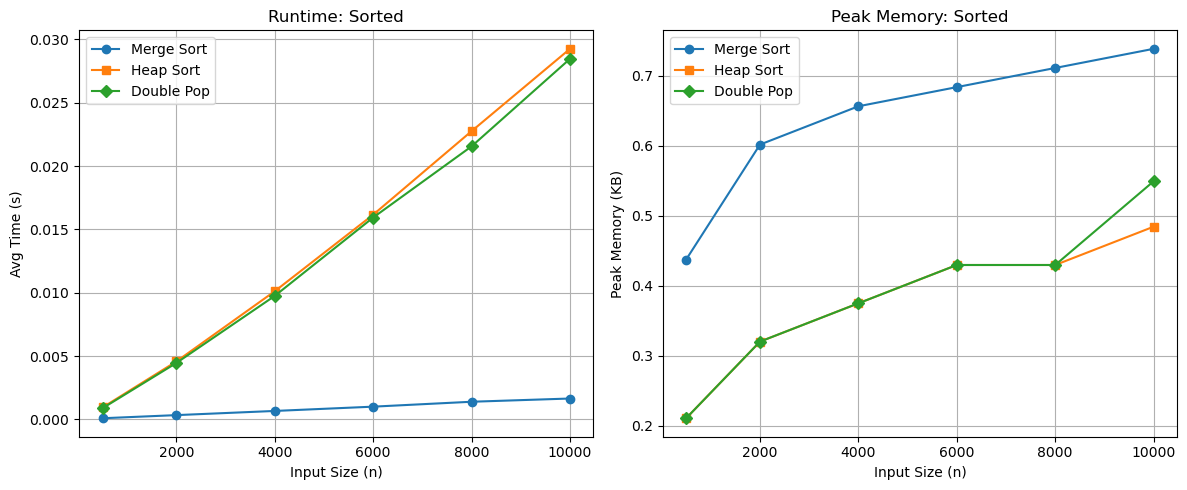

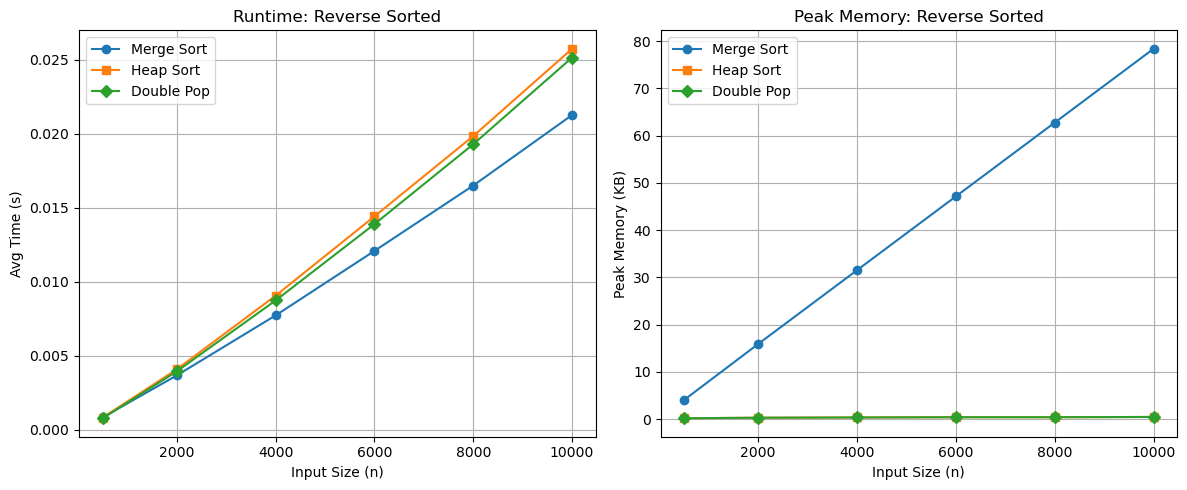

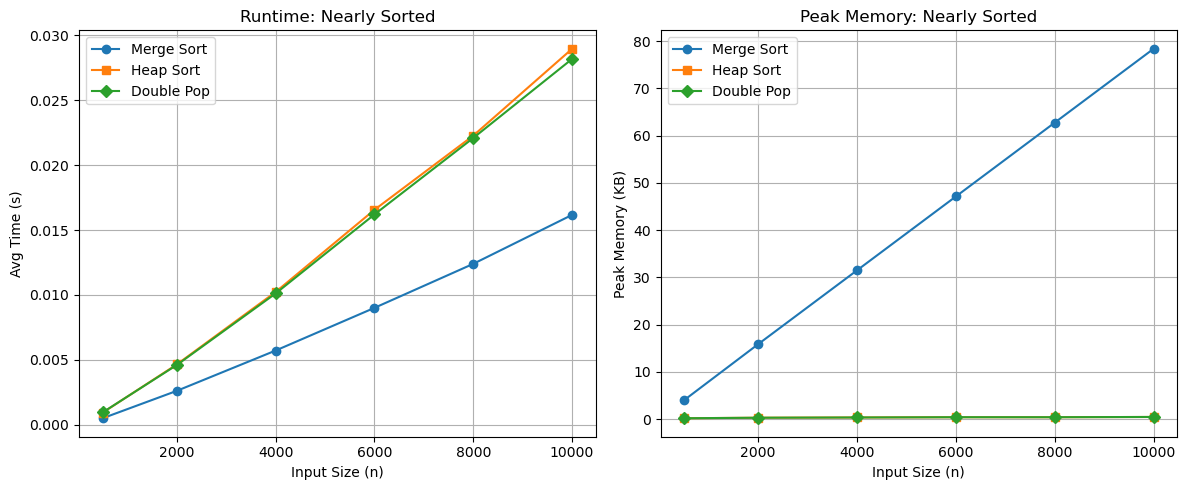

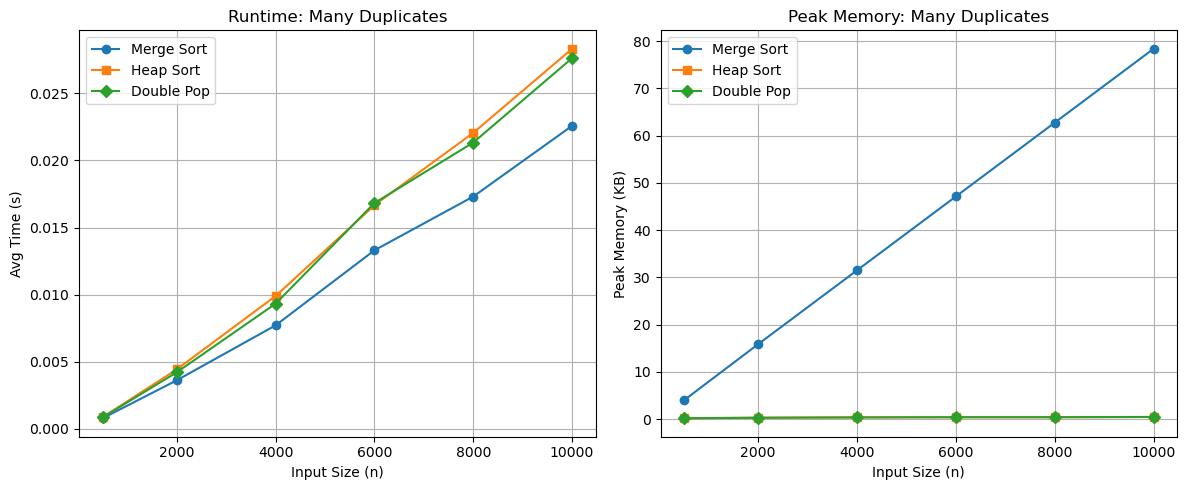

In [34]:
for type_name in results:
    times = results[type_name]
    mems = mem_results[type_name]

    fig, (ax_time, ax_mem) = plt.subplots(1, 2, figsize=(12, 5))

    ax_time.plot(sizes, times["merge"], marker='o', label="Merge Sort")
    ax_time.plot(sizes, times["heap"],  marker='s', label="Heap Sort")
    ax_time.plot(sizes, times["dpop"],  marker='D', label="Double Pop")
    ax_time.set_title(f"Runtime: {type_name}")
    ax_time.set_xlabel("Input Size (n)")
    ax_time.set_ylabel("Avg Time (s)")
    ax_time.legend()
    ax_time.grid(True)

    ax_mem.plot(sizes, mems["merge"], marker='o', label="Merge Sort")
    ax_mem.plot(sizes, mems["heap"],  marker='s', label="Heap Sort")
    ax_mem.plot(sizes, mems["dpop"],  marker='D', label="Double Pop")
    ax_mem.set_title(f"Peak Memory: {type_name}")
    ax_mem.set_xlabel("Input Size (n)")
    ax_mem.set_ylabel("Peak Memory (KB)")
    ax_mem.legend()
    ax_mem.grid(True)

    plt.tight_layout()
    plt.show()
